## Linear Regression

In [ ]:
import math, time, torch, os
import numpy as np
from d2l import torch as d2l
import matplotlib.pyplot as plt
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma ** 2)
    return p * np.exp(-0.5 * (x - mu)**2 / sigma**2)

# current directory:
curr_dir = os.path.dirname(os.path.abspath(__file__))
os.makedirs(os.path.join(curr_dir, 'data/normal'), exist_ok=True)

x = np.arange(-7, 7, 0.01)
params = [(0, 1), (0, 2), (3, 1), (0, 3), (0, 4)]

d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x', ylabel='p(x)', figsize=(6, 4), legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])
plt.savefig(os.path.join(curr_dir, 'data/normal/normal_distribution.png'))

## OOP for Implementation

In [2]:
import time, torch, os
import numpy as np
from torch import nn
from d2l import torch as d2l

def add_to_class(Class): #@save
    # registers functions as methods in created class
    def wrapper(obj):
        setattr(Class, obj.__name__, obj)
    return wrapper

class A:
    def __init__(self):
        self.b = 1
a = A()

In [3]:
@add_to_class(A)
def do(self):
    print(f'{self.b=}')
a.do()

self.b=1


In [6]:
class HyperParameters: #@save
    def save_hyperparameters(self, ignore=[]):
        raise NotImplemented

class B(d2l.HyperParameters):
    def __init__(self, a, b, c):
        self.save_hyperparameters(ignore=['c'])
        print('self.a =', self.a, 'self.b =', self.b)
        print('There is no self.c =', not hasattr(self, 'c'))

b = B(1, 2, 3)

self.a = 1 self.b = 2
There is no self.c = True


In [ ]:
class ProgressBoard(d2l.HyperParameters): #@save
    def __init(self, xlabel=None, ylabel=None, xlim=None, 
               ylim=None, xscale='linear', yscale='linear',
               ls=['-','--','-.',':'], colors=['C0', 'C1', 'C2', 'C3'],
               fig=None, axes=None, figsize=(3.5, 2.5), display=True):
        self.save_hyperparameters()
    
    def draw(self, x,y,label,every_n=1):
        raise NotImplemented
    

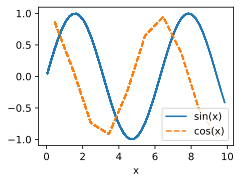

In [9]:
board=d2l.ProgressBoard('x')
for x in np.arange(0,10,0.1):
    board.draw(x, np.sin(x), 'sin(x)', every_n=2)
    board.draw(x, np.cos(x), 'cos(x)', every_n=10)

In [ ]:
class Module(nn.Module, d2l.HyperParameters): #@save
    def __init__(self, plot_train_per_epoch=2, plot_valid_per_epoch=1): # stores learnable parameters
        super().__init__()
        self.save_hyperparameters()
        self.board = ProgressBoard()
        
    def loss(self, y_hat, y): # computes the loss function
        raise NotImplementedError
    
    def forward(self, X): # defined so is easier to perform formward pass w nn
        assert hasattr(self, 'net'), 'Neural netword is defined'
        return self.net(X)
    
    def plot(self, key, value, train):
        """Plot a point in animation."""
        assert hasattr(self, 'trainer'), 'Trainer is not inited'
        self.board.xlabel = 'epoch'
        if train:
            x = self.trainer.train_batch_idx / \
                self.trainer.num_train_batches
            n = self.trainer.num_train_batches / \
                self.plot_train_per_epoch
        else:
            x = self.trainer.epoch + 1
            n = self.trainer.num_val_batches / \
                self.plot_valid_per_epoch
        self.board.draw(x, value.to(d2l.cpu()).detach().numpy(),
                        ('train_' if train else 'val_') + key,
                        every_n=int(n))

    def training_step(self, batch): # take in a data batch and calculate the loss
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=True)
        return l

    def validation_step(self, batch): # report the loss on the validation set
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=False)

    def configure_optimizers(self):
        raise NotImplementedError

In [ ]:
class DataModule(d2l.HyperParameters):  #@save
    """The base class of data."""
    def __init__(self, root='../data', num_workers=4):
        self.save_hyperparameters()

    def get_dataloader(self, train): # dataloader is a python generator that yields batches of data
        raise NotImplementedError

    def train_dataloader(self): # dataloader for training set
        return self.get_dataloader(train=True)

    def val_dataloader(self): # dataloader for validation set
        return self.get_dataloader(train=False)

In [ ]:
class Trainer(d2l.HyperParameters):  #@save
    """The base class for training models with data."""
    # trainer class trains learnable parameters in the modeule class with data from the datamodule class
    
    def __init__(self, max_epochs, num_gpus=0, gradient_clip_val=0):
        self.save_hyperparameters()
        assert num_gpus == 0, 'No GPU support yet'

    def prepare_data(self, data):
        self.train_dataloader = data.train_dataloader()
        self.val_dataloader = data.val_dataloader()
        self.num_train_batches = len(self.train_dataloader)
        self.num_val_batches = (len(self.val_dataloader)
                                if self.val_dataloader is not None else 0)

    def prepare_model(self, model):
        model.trainer = self
        model.board.xlim = [0, self.max_epochs]
        self.model = model

    def fit(self, model, data): # iterates over the training and validation data for a number of epochs, updating the model parameters using the optimizer
        self.prepare_data(data)
        self.prepare_model(model)
        self.optim = model.configure_optimizers()
        self.epoch = 0
        self.train_batch_idx = 0
        self.val_batch_idx = 0
        for self.epoch in range(self.max_epochs):
            self.fit_epoch()

    def fit_epoch(self):
        raise NotImplementedError

## Synthetic Regression Data

In [ ]:
# %matplotlib inline
import random
import torch
from d2l import torch as d2l

class SyntheticRegressionData(d2l.DataModule): #@save
    '''syntheitc data for linreg'''
    
    def __init__(self, w, b, noise=0.01,num_train=1000, num_val=1000, batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        n=num_train + num_val # defines the total number of samples
        self.X = torch.rand(n, len(w)) # randomly generates n samples of features with dimension len(w)
        noise = torch.randn(n, 1) * noise # gaussian noise
        self.y = torch.matmul(self.X, w.reshape((-1,1))) + b + noise # we have to transpose w
        
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
print('features:', data.X[0],'\nlabel:', data.y[0])


In [16]:
@d2l.add_to_class(SyntheticRegressionData)
def get_dataloader(self, train):
    if train:
        indices = list(range(0, self.num_train))
        random.shuffle(indices) #exchangability
    else:
        indices = list(range(self.num_train, self.num_train+self.num_val))
    for i in range(0, len(indices), self.batch_size):
        batch_indices = torch.tensor(indices[i: i+self.batch_size])
        yield self.X[batch_indices], self.y[batch_indices]

In [36]:
# existing loader
@d2l.add_to_class(d2l.DataModule)  #@save
def get_tensorloader(self, tensors, train, indices=slice(0, None)):
    tensors = tuple(a[indices] for a in tensors)
    dataset = torch.utils.data.TensorDataset(*tensors)
    return torch.utils.data.DataLoader(dataset, self.batch_size,
                                       shuffle=train)

@d2l.add_to_class(SyntheticRegressionData)  #@save
def get_dataloader(self, train):
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader((self.X, self.y), train, i)

In [37]:
X, y = next(iter(data.train_dataloader()))
print('X shape:', X.shape, '\ny shape:', y.shape)

X shape: torch.Size([32, 2]) 
y shape: torch.Size([32, 1])


## Linear Regression Implementation from Scratch

In [42]:
import os, torch, time, math
from d2l import torch as d2l

class LinearRegressionScratch(d2l.Module): #@save
    def __init__(self, num_inputs, lr, sigma=0.1):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(0, sigma, (num_inputs, 1), requires_grad=True) # init the weights w gaussian noise
        self.b = torch.zeros(1, requires_grad=True) # init bias w 0
    
@d2l.add_to_class(LinearRegressionScratch)  #@save
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

@d2l.add_to_class(LinearRegressionScratch)  #@save
def loss(self, y_hat, y):
    l = (y_hat - y) ** 2 / 2 # mse loss
    return l.mean()
    

In [43]:
class SGD(d2l.HyperParameters): #@save
    def __init__(self, params, lr):
        self.save_hyperparameters()
    
    def step(self):
        for param in self.params:
            param -= self.lr * param.grad # go in the direciton of the negative gradient
    
    def zero_grad(self): # this is necessary because pytorch accumulates gradients by default, so we need to zero them out after each step
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

@d2l.add_to_class(LinearRegressionScratch)  #@save
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

In [44]:
@d2l.add_to_class(d2l.Trainer) #@save
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer) #@save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader: # for each batch in the data
        loss = self.model.training_step(self.prepare_batch(batch)) # first calculate the loss for the batch given the model parameters
        self.optim.zero_grad() # zero out the gradients
        with torch.no_grad():
            loss.backward() # compute the gradients
            if self.gradient_clip_val > 0:
                self.clip_gradients(self.gradient_clip_val, self.model) # this is to prevent exploding gradients
            self.optim.step() # update the model parameters
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

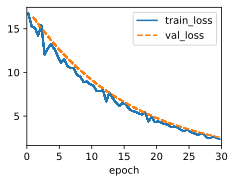

In [49]:
model = LinearRegressionScratch(2, lr=0.001)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer=d2l.Trainer(max_epochs=30)
trainer.fit(model, data)

In [50]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([ 0.8425, -1.1864])
error in estimating b: tensor([1.5917])


## Weight Decay

In [57]:
import torch, os, math, time
from torch import nn
from d2l import torch as d2l

# weight decay = l2 reg
'''
we want simple models; to make sure we have simple models, we can try to restrict/regularize the model parameters.
we can view ther model aprameters as a vector,a nd the weights their distance from zero. 
add this reg term to the objective function to penalize large weights and penalize the predicitve error.
'''

class Data(d2l.DataModule):
    def __init__(self, num_train, num_val, num_inputs, batch_size):
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn(n, num_inputs)
        noise = torch.randn(n, 1) * 0.01
        w, b = torch.ones((num_inputs, 1)) * 0.01, 0.05
        self.y = torch.matmul(self.X, w) + b + noise

    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader([self.X, self.y], train, i)
    
def l2_penalty(w):
    return (w**2).sum() / 2

class WeightDecayScratch(d2l.LinearRegressionScratch):
    def __init__(self, num_inputs, lambd, lr, sigma=0.01):
        super().__init__(num_inputs, lr, sigma)
        self.save_hyperparameters()
    
    def loss(self, y_hat, y):
        return (super().loss(y_hat, y) + self.lambd * l2_penalty(self.w))

data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)
def train_scratch(lambd):
    model = WeightDecayScratch(num_inputs=200, lambd=lambd, lr=0.01)
    model.board.yscale='log'
    trainer.fit(model, data)
    print('L2 norm of w:', float(l2_penalty(model.w)))

L2 norm of w: 0.01045285165309906


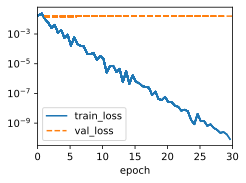

In [ ]:
train_scratch(0)

L2 norm of w: 0.0005470537580549717


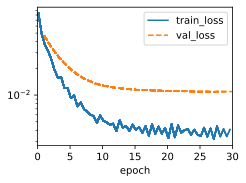

In [60]:
train_scratch(4.65)